In [7]:
import json
import re
from abc import ABC, abstractmethod
from dataclasses import dataclass
from datetime import datetime
from enum import Enum
from typing import Any

import pandas as pd
from matplotlib import pyplot as plt

In [8]:
TRANSACTIONS_CSV = "data/transactions_dirty.csv"
TRANSACTIONS_JSON = "data/transactions_dirty.json"

## Задание 1.
Реализуйте базовый класс Account, который моделирует поведение
банковского счёта. Этот класс должен не только выполнять базовые
операции, но и вести детальный учёт всех действий, а также предоставлять аналитику по истории операций.

### Этап 1. Реализация базового класса Account
Класс должен быть инициализирован с параметрами:
- account_holder (str) — имя владельца счёта;
- balance (float, по умолчанию 0) — начальный баланс счёта, не может
быть отрицательным.
Атрибуты:
- _account_counter — приватный атрибут для хранения количества
созданных счетов. Отсчет начинается с 1000;
- holder — хранит имя владельца;
- account_number — хранит номер счёта;
- _balance — приватный атрибут для хранения текущего баланса;
- operations_history — список или другая структура для хранения
истории операций.

*Важно*: каждая операция должна храниться не просто как число, а как
структурированная информация, например, словарь, кортеж или класс.
Минимальный набор данных для операции: тип операции ('deposit' или
'withdraw'), сумма, дата и время операции, текущий баланс после операции, статус ('success' или 'fail').


### Этап 2. Реализация методов
1. __init__(self, account_holder, balance=0) — конструктор. Обратите
внимание, что в конструкторе должен автоматически формироваться
номер счёта в формате ‘ACC-XXXX’, где XXXX — порядковый номер
счёта;
2. deposit(self, amount) — метод для пополнения счёта:
- принимает сумму (должна быть положительной), попытка
положить отрицательную сумму, должна вызывать исключение;
- в случае успеха обновляет баланс и добавляет запись в историю
операций.
3. withdraw(self, amount) — метод для снятия средств:
- принимает сумму (должна быть положительной);
- проверяет, достаточно ли средств на счёте, если нет — операция
не проходит, но ее попытка с статусом 'fail' все равно фиксируется
в истории;
- в случае успеха обновляет баланс и добавляет запись в историю.
4. get_balance(self) — метод, который возвращает текущий баланс.
5. get_history(self) — метод, который возвращает историю операций

*Важно*: продумайте, в каком формате его вернуть. Для работы с датой и
временем используйте модуль datetime. Получить текущее время можно с
помощью datetime.now()

### Этап 3. Визуализация истории операций. Дополнительное задание для
претендующих на оценку 8 и выше баллов (выполняется по желанию).
1. Создайте метод plot_history(self), который использует библиотеку
Pandas для создания датафрейма из истории операций.
2. Продумайте, с помощью какой библиотеки можно отобразить
изменение баланса с течением времени. Постройте простой
линейный график, где по оси X будет время операции, а по оси Y —
баланс после каждой операции. График должен иметь заголовок,
подписи осей


## Задание 2.
### Этап 4. Реализация наследования
1. Реализуйте два класса CheckingAccount (расчётный счёт) и
SavingsAccount (сберегательный счёт), которые отражают абстракцию
базового поведения банковских аккаунтов:
 наследуются от базового класса Account;
 хранят атрибут класса account_type.
2. Класс SavingsAccount (сберегательный счёт) дополнительно должен
реализовывать метод расчёта процентов на остаток
apply_interest(self, rate) (например, 7% на остаток).
3. Класс SavingsAccount (сберегательный счёт) позволяет снимать
деньги только до определенного порога баланса: нельзя снять
больше 50% от баланса. Переопределите метод снятия со счёта
4. Реализуйте валидацию на отрицательные суммы и корректность
имени владельца:
- имя владельца счёта должно быть в формате «Имя Фамилия» с
заглавных букв, кириллицей или латиницей, иначе — должно
вызываться исключение;
- попытка положить отрицательную сумму должна вызывать
исключение.
5. Реализуйте метод для анализа истории транзакций по размеру и дате:
- метод должен выводить последние n крупных операций


## Задание 3. Дополнительное задание для претендущих на оценку 9-10 баллов (выполняется по желанию).
Перед началом работы загрузите из личного кабинете файлы, на которых
можно проверить код с «грязными» данными: transactions_dirty.csv и
transactions_dirty.json.
Реализуйте для классов аккаунтов CheckingAccount (расчётный счёт) и
SavingsAccount (сберегательный счёт) два метода:
- Метод загрузки истории в аккаунт из файла с транзакциями (файл
транзакций общий для всех аккаунтов, необходимо учесть
фильтрацию загружаемых значений).
- Метод clean_history(), который ищет ошибки в данных перед записью
транзакций в историю (опечатки, отрицательные суммы, неверные
даты). Обратите внимание, что для SavingsAccount (сберегательный
счёт) доступно три типа операции (deposit, withdraw и interest), в то
время как для CheckingAccount (расчётный счёт) доступны только два
типа операции (deposit, withdraw). Все данные с ошибками считаем
невалидными и не записываем в историю операций.
- После загрузки истории операций в аккаунт, баланс счёта должен
обновиться


In [9]:
class OperationType(Enum):
    """Enumeration of possible operation types for an account."""
    DEPOSIT = "deposit"   # Adding funds to the account
    WITHDRAW = "withdraw" # Withdrawing funds from the account
    INTEREST = "interest" # Interest accrual (only for savings accounts)


class OperationStatus(Enum):
    """Enumeration of possible outcomes of an operation."""
    SUCCESS = "success"   # Operation completed successfully
    FAIL = "fail"         # Operation failed (e.g., insufficient funds)


class AccountType(Enum):
    """Enumeration of supported account types."""
    CHECKING_ACCOUNT = "checking"  # Regular checking account (no interest)
    SAVINGS_ACCOUNT = "savings"    # Savings account (supports interest accrual)


@dataclass
class Operation:
    """
    Represents a single account operation with full audit information.

    Attributes:
        operation_type (OperationType): The type of the operation (deposit, withdraw, interest).
        operation_status (OperationStatus): The result of the operation (success/fail).
        timestamp (datetime): The date and time when the operation occurred.
        amount (float): The amount of money involved in the operation.
        balance_after (float): The account balance after the operation was applied.
    """
    operation_type: OperationType
    operation_status: OperationStatus
    timestamp: datetime
    amount: float
    balance_after: float


In [10]:
class Account(ABC):
    """
    Base abstract class representing a generic bank account.

    Provides core functionality for all account types:
      - balance management (deposit / withdraw)
      - transaction history tracking
      - file import (JSON / CSV)
      - validation and consistency checks
      - visualization and analytics tools
    """

    account_number: str
    holder: str
    operations_history: list[Operation]
    _account_counter: int = 1000
    _balance: float

    def __init__(self, account_holder: str, balance: float = 0):
        """Initialize a new account with holder name and optional starting balance."""
        self._validate_name(account_holder)
        self._validate_balance(balance)

        self.holder = account_holder
        self._balance = balance
        self.account_number = f"ACC-{Account._account_counter:06d}"
        self.operations_history = []
        Account._account_counter += 1

    def deposit(self, amount: float):
        """Deposit money into the account."""
        self._validate_amount(amount)
        self._balance += amount

        operation = Operation(
            operation_type=OperationType.DEPOSIT,
            operation_status=OperationStatus.SUCCESS,
            timestamp=datetime.now(),
            amount=amount,
            balance_after=self._balance,
        )
        self.operations_history.append(operation)

    def withdraw(self, amount: float):
        """Withdraw money from the account (with validation of sufficient funds)."""
        self._validate_amount(amount)

        if self._balance < amount:
            operation_status = OperationStatus.FAIL
        else:
            operation_status = OperationStatus.SUCCESS
            self._balance -= amount

        operation = Operation(
            operation_type=OperationType.WITHDRAW,
            operation_status=operation_status,
            timestamp=datetime.now(),
            amount=amount,
            balance_after=self._balance,
        )
        self.operations_history.append(operation)

    def get_balance(self) -> float:
        """Return the current account balance."""
        return self._balance

    def get_history(self) -> pd.DataFrame:
        """Return the operation history as a pandas DataFrame."""
        return pd.DataFrame(
            [
                {
                    "account_number": self.account_number,
                    "account_type": self._get_account_type().value,
                    "date": op.timestamp,
                    "operation": op.operation_type.value,
                    "amount": op.amount,
                    "balance_after": op.balance_after,
                    "status": op.operation_status.value,
                }
                for op in self.operations_history
            ]
        )

    def plot_history(self):
        """Plot account balance changes over time using matplotlib."""
        if not self.operations_history:
            print("No operations to display.")
            return

        history = self.get_history()
        plt.figure(figsize=(8, 4))
        plt.plot(history["date"], history["balance_after"], marker="o", linestyle="-")
        plt.title(f"Balance over time for account {self.account_number}")
        plt.xlabel("Operation date")
        plt.ylabel("Balance after operation")
        plt.xticks(rotation=45)
        plt.grid(True)
        plt.tight_layout()
        plt.show()

    def analyze_history(self, n: int = 5):
        """Display the top `n` largest transactions."""
        if not self.operations_history:
            print("No transactions to analyze.")
            return

        df = self.get_history().sort_values(by="amount", ascending=False).head(n)
        print(f"Top {n} largest transactions for account {self.account_number}:")
        print(df.to_string(index=False))

    def from_json(self, path: str):
        """Load transaction history from a JSON file."""
        with open(path, "r", encoding="utf-8") as f:
            records = json.load(f)
        self._load_transaction_records(records)

    def from_csv(self, path: str):
        """Load transaction history from a CSV file."""
        df = pd.read_csv(path)
        records = df.to_dict(orient="records")
        self._load_transaction_records(records)

    def clean_history(self, data: dict[str, Any]) -> Operation | None:
        """
        Validate and normalize a single transaction record.

        Returns:
            Operation if valid, None if record is invalid or belongs to another account.
        """
        try:
            account_number = self._read_account_number(data)
            if not self._is_same_account_number(account_number):
                return None

            account_type = self._read_account_type(data)
            if not self._is_same_account_type(account_type):
                return None

            operation_type = self._read_operation_type(data)
            if not self._is_valid_operation_type(operation_type):
                return None

            operation = Operation(
                operation_type=operation_type,
                operation_status=self._read_operation_status(data),
                timestamp=self._read_timestamp(data),
                amount=self._read_amount(data),
                balance_after=self._read_balance_after(data),
            )
            return operation

        except ValueError as ex:
            print(f"Skipping invalid record: {ex}")
            return None

    def _load_transaction_records(self, transactions: list[dict[str, Any]]):
        """Load operations from a list of transaction dicts."""
        for trx in transactions:
            op = self.clean_history(trx)
            if op:
                self.operations_history.append(op)

        # Sort by date to ensure chronological order
        self.operations_history.sort(key=lambda op: op.timestamp)

        # Set current balance to the last valid balance
        if self.operations_history:
            self._balance = self.operations_history[-1].balance_after

    def _validate_name(self, name: str):
        """Ensure holder name follows 'First Last' format with capitalized letters."""
        if not re.match(r"^([A-ZА-Я][a-zа-яё'-]+)\s([A-ZА-Я][a-zа-яё'-]+)$", name):
            raise ValueError(
                "The account holder's name must be in the format 'First Last'"
                " with capitalized letters (Cyrillic or Latin)."
            )

    def _validate_amount(self, amount: float):
        """Ensure transaction amount is positive."""
        if amount <= 0:
            raise ValueError("The transaction amount must be positive.")

    def _validate_balance(self, balance: float):
        """Ensure initial balance is zero or positive."""
        if balance < 0:
            raise ValueError("The account balance must be zero or positive.")

    def _read_account_number(self, data: dict[str, Any]) -> str:
        account_number = data.get("account_number")
        if not isinstance(account_number, str) or not re.match(
            r"^ACC-\d{6}$", account_number
        ):
            raise ValueError("Invalid account number format (expected 'ACC-XXXXXX').")
        return account_number

    def _read_account_type(self, data: dict[str, Any]) -> AccountType:
        account_type_str = data.get("account_type")
        try:
            return AccountType(account_type_str)
        except ValueError:
            raise ValueError(f"Unknown account type: {account_type_str}")

    def _read_operation_type(self, data: dict[str, Any]) -> OperationType:
        operation_type_str = data.get("operation")
        try:
            return OperationType(operation_type_str)
        except ValueError:
            raise ValueError(f"Unknown operation type: {operation_type_str}")

    def _read_operation_status(self, data: dict[str, Any]) -> OperationStatus:
        status_str = data.get("status")
        try:
            return OperationStatus(status_str)
        except ValueError:
            raise ValueError(f"Invalid transaction status: {status_str}")

    def _read_timestamp(self, data: dict[str, Any]) -> datetime:
        date_str = data.get("date")
        try:
            return datetime.strptime(date_str, "%Y-%m-%d %H:%M:%S")
        except Exception:
            raise ValueError(
                f"Invalid date format: {date_str}. Expected 'YYYY-MM-DD HH:MM:SS'."
            )

    def _read_amount(self, data: dict[str, Any]) -> float:
        amount = data.get("amount")
        if not isinstance(amount, (int, float)) or amount <= 0:
            raise ValueError("Transaction amount must be a positive number.")
        return float(amount)

    def _read_balance_after(self, data: dict[str, Any]) -> float:
        balance_after = data.get("balance_after")
        if not isinstance(balance_after, (int, float)) or balance_after < 0:
            raise ValueError("Balance after transaction must be a non-negative number.")
        return float(balance_after)

    def _is_same_account_type(self, account_type: AccountType) -> bool:
        """Check if record belongs to the same account type."""
        return account_type == self._get_account_type()

    def _is_same_account_number(self, account_number: str) -> bool:
        """Check if record belongs to this account number."""
        return account_number == self.account_number

    def _is_valid_operation_type(self, operation_type: OperationType) -> bool:
        """Check if operation type is supported by this account."""
        return operation_type in self._get_supported_operation_types()

    @abstractmethod
    def _get_account_type(self) -> AccountType:
        """Return the account type (checking or savings)."""
        ...

    @abstractmethod
    def _get_supported_operation_types(self) -> list[OperationType]:
        """Return the list of allowed operation types for this account."""
        ...

In [11]:
class SavingsAccount(Account):
    """
    Savings account with deposit, withdraw, and interest operations.

    Withdrawals are limited to 50% of current balance.
    Interest can be applied using a percentage rate.
    """

    account_type: AccountType = AccountType.SAVINGS_ACCOUNT
    _supported_operation_types: list[OperationType] = [
        OperationType.DEPOSIT,
        OperationType.WITHDRAW,
        OperationType.INTEREST,
    ]

    def apply_interest(self, rate: float):
        """
        Apply interest to the account balance.

        Args:
            rate (float): Interest rate in percent (0 < rate <= 100).
        """
        if not (0 < rate <= 100):
            raise ValueError("The interest rate must be in range (0, 100].")

        amount = self._balance * rate / 100
        self._balance += amount

        operation = Operation(
            operation_type=OperationType.INTEREST,
            operation_status=OperationStatus.SUCCESS,
            timestamp=datetime.now(),
            amount=amount,
            balance_after=self._balance
        )
        self.operations_history.append(operation)

    def withdraw(self, amount: float):
        """
        Withdraw money with a 50% balance limit.

        Args:
            amount (float): Amount to withdraw.

        Raises:
            ValueError: If amount is not positive.
        """
        if amount <= 0:
            raise ValueError("The withdrawal amount must be positive.")

        # Limit: cannot withdraw more than 50% of current balance
        if amount > self._balance * 0.5:
            operation_status = OperationStatus.FAIL
        else:
            operation_status = OperationStatus.SUCCESS
            self._balance -= amount

        operation = Operation(
            operation_type=OperationType.WITHDRAW,
            operation_status=operation_status,
            timestamp=datetime.now(),
            amount=amount,
            balance_after=self._balance
        )
        self.operations_history.append(operation)

    def _get_account_type(self) -> AccountType:
        """Return account type (savings)."""
        return self.account_type

    def _get_supported_operation_types(self) -> list[OperationType]:
        """Return list of supported operations for savings account."""
        return self._supported_operation_types


In [12]:
class CheckingAccount(Account):
    """
    Checking account with deposit and withdraw operations.

    No interest operations are allowed.
    """

    account_type: AccountType = AccountType.CHECKING_ACCOUNT
    _supported_operation_types: list[OperationType] = [
        OperationType.DEPOSIT,
        OperationType.WITHDRAW,
    ]

    def _get_account_type(self) -> AccountType:
        """Return account type (checking)."""
        return self.account_type

    def _get_supported_operation_types(self) -> list[OperationType]:
        """Return list of supported operations for checking account."""
        return self._supported_operation_types

## Пример работы 1

Skipping invalid record: Invalid date format: 28/09/2025 22:17. Expected 'YYYY-MM-DD HH:MM:SS'.
Skipping invalid record: Transaction amount must be a positive number.
Skipping invalid record: Unknown operation type: None
Skipping invalid record: Invalid date format: 2025-17-34 12:00:00. Expected 'YYYY-MM-DD HH:MM:SS'.
Skipping invalid record: Invalid date format: 06/10/2025 22:17. Expected 'YYYY-MM-DD HH:MM:SS'.
Skipping invalid record: Unknown operation type: diposit
Skipping invalid record: Invalid date format: 2023-16-40 12:00:00. Expected 'YYYY-MM-DD HH:MM:SS'.
Skipping invalid record: Invalid transaction status: succes

Transaction history:
   account_number account_type                date operation  amount  \
0      ACC-100001     checking 2025-09-27 22:17:26   deposit   921.0   
1      ACC-100001     checking 2025-09-27 22:17:26   deposit   607.0   
2      ACC-100001     checking 2025-09-28 22:17:26   deposit   488.0   
3      ACC-100001     checking 2025-09-29 22:17:26   depos

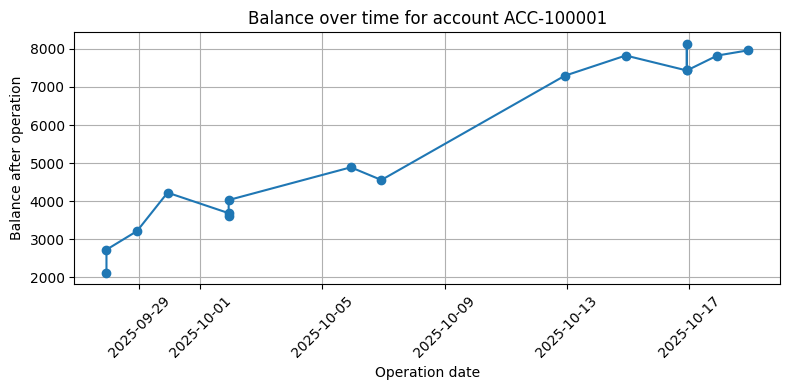

In [13]:
acc = CheckingAccount("John Doe", 0.0)
acc.account_number = "ACC-100001"
acc.from_json(TRANSACTIONS_JSON)
history = acc.get_history()

print()
print("Transaction history:")
print(history)

print()
acc.analyze_history()

print()
acc.plot_history()

## Пример работы 2

Skipping invalid record: Invalid date format: 2023-22-32 12:00:00. Expected 'YYYY-MM-DD HH:MM:SS'.
Skipping invalid record: Invalid date format: 04/10/2025 22:17. Expected 'YYYY-MM-DD HH:MM:SS'.
Skipping invalid record: Transaction amount must be a positive number.
Skipping invalid record: Invalid date format: 09/10/2025 22:17. Expected 'YYYY-MM-DD HH:MM:SS'.
Skipping invalid record: Unknown operation type: diposit
Skipping invalid record: Transaction amount must be a positive number.
Skipping invalid record: Invalid transaction status: succes
Skipping invalid record: Unknown operation type: wdraw
Skipping invalid record: Invalid date format: 09/10/2025 22:17. Expected 'YYYY-MM-DD HH:MM:SS'.
Skipping invalid record: Invalid transaction status: succes

Transaction history:
   account_number account_type                date operation  amount  \
0      ACC-100002      savings 2025-09-27 22:17:26   deposit  469.00   
1      ACC-100002      savings 2025-09-27 22:17:26  withdraw  392.00   
2

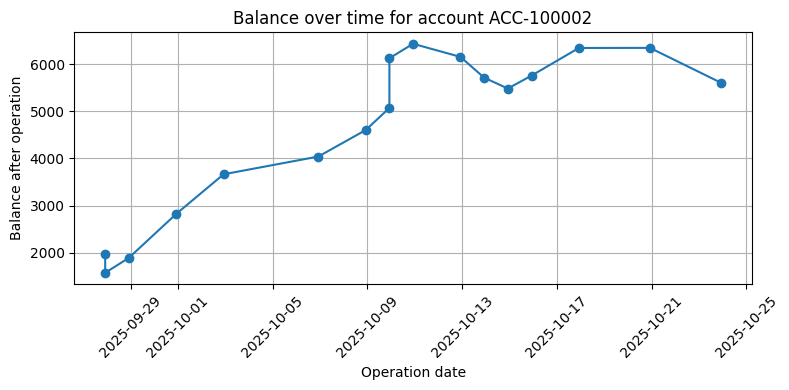

In [14]:
acc = SavingsAccount("Jean Doe", 0.0)
acc.account_number = "ACC-100002"
acc.from_csv(TRANSACTIONS_CSV)
history = acc.get_history()

print()
print("Transaction history:")
print(history)

print()
acc.analyze_history()

print()
acc.plot_history()

## Пример работы 3

Skipping invalid record: Transaction amount must be a positive number.
Skipping invalid record: Unknown operation type: wdraw
Skipping invalid record: Invalid date format: 2023-14-33 12:00:00. Expected 'YYYY-MM-DD HH:MM:SS'.
Skipping invalid record: Transaction amount must be a positive number.

Transaction history:
   account_number account_type                date operation  amount  \
0      ACC-100003     checking 2025-10-02 22:17:26   deposit   233.0   
1      ACC-100003     checking 2025-10-05 22:17:26   deposit   720.0   
2      ACC-100003     checking 2025-10-06 22:17:26   deposit   296.0   
3      ACC-100003     checking 2025-10-08 22:17:26   deposit   956.0   
4      ACC-100003     checking 2025-10-10 22:17:26   deposit   754.0   
5      ACC-100003     checking 2025-10-10 22:17:26   deposit   255.0   
6      ACC-100003     checking 2025-10-14 22:17:26  withdraw   131.0   
7      ACC-100003     checking 2025-10-16 22:17:26   deposit   898.0   
8      ACC-100003     checking 202

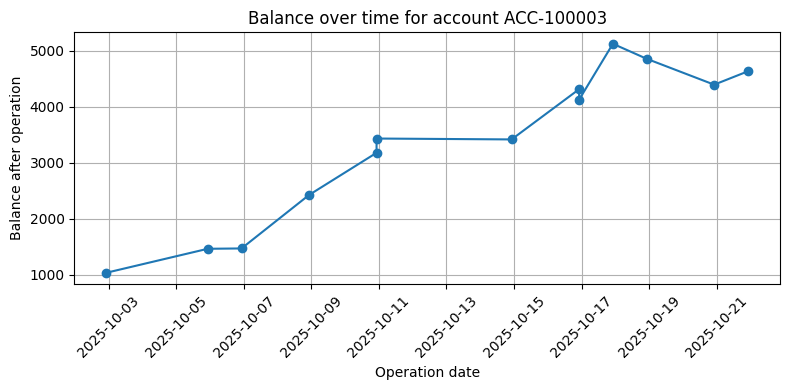

In [15]:
acc = CheckingAccount("John Doe", 0.0)
acc.account_number = "ACC-100003"
acc.from_json(TRANSACTIONS_JSON)
history = acc.get_history()

print()
print("Transaction history:")
print(history)

print()
acc.analyze_history()

print()
acc.plot_history()

## Пример работы 4

Skipping invalid record: Unknown operation type: diposit
Skipping invalid record: Invalid transaction status: succes
Skipping invalid record: Transaction amount must be a positive number.
Skipping invalid record: Invalid transaction status: succes
Skipping invalid record: Invalid transaction status: succes
Skipping invalid record: Invalid date format: 01/10/2025 22:17. Expected 'YYYY-MM-DD HH:MM:SS'.
Skipping invalid record: Invalid date format: 2024-17-35 12:00:00. Expected 'YYYY-MM-DD HH:MM:SS'.
Skipping invalid record: Invalid transaction status: succes
Skipping invalid record: Transaction amount must be a positive number.
Skipping invalid record: Invalid date format: 2025-16-35 12:00:00. Expected 'YYYY-MM-DD HH:MM:SS'.
Skipping invalid record: Unknown operation type: nan
Skipping invalid record: Invalid date format: 01/10/2025 22:17. Expected 'YYYY-MM-DD HH:MM:SS'.

Transaction history:
   account_number account_type                date operation  amount  \
0      ACC-100004      s

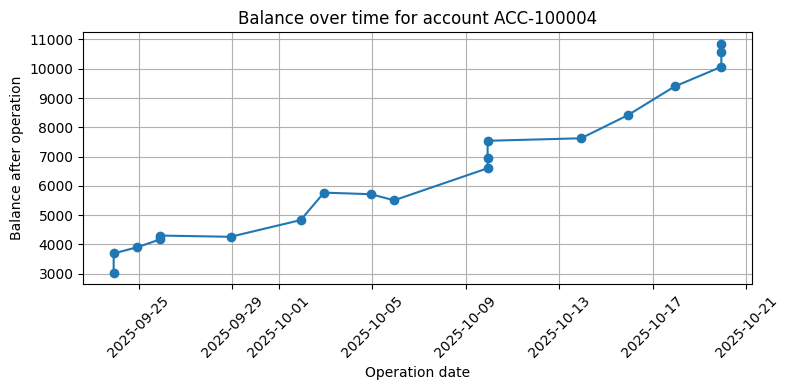

In [16]:
acc = SavingsAccount("Jean Doe", 0.0)
acc.account_number = "ACC-100004"
acc.from_csv(TRANSACTIONS_CSV)
history = acc.get_history()

print()
print("Transaction history:")
print(history)

print()
acc.analyze_history()

print()
acc.plot_history()